## Modular flare-up classification workflow

This notebook uses the reusable modules in `model/` to predict **tomorrow's asthma flare-up** (binary classification), following `Asthma_binary.ipynb`. Raw CSV files should be placed in `model/data/raw/` after downloading them from Edinburgh DataShare.

In [3]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "model" / "train.py").exists() and (PROJECT_ROOT / "asthma-app" / "model" / "train.py").exists():
    PROJECT_ROOT = PROJECT_ROOT / "asthma-app"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Pick up latest code after module refactors (avoids stale kernel imports)
for module_name in list(sys.modules):
    if module_name == "model" or module_name.startswith("model."):
        del sys.modules[module_name]

from model.feature_engineering import build_binary_daily_dataset, default_binary_feature_columns
from model.train import evaluate_global_chronological, train_final_model, chronological_user_split
from model.inference_new import predict_dataframe, save_model

DATA_DIR = PROJECT_ROOT / "model" / "data" / "raw"
print(f"Project root: {PROJECT_ROOT}")
csv_files = sorted(DATA_DIR.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(
        f"No CSV files found in {DATA_DIR}. Download the AAMOS archive and extract the anonymized CSVs there."
    )

def table_name_from_path(path: Path) -> str:
    name = path.stem
    prefix = "anonym_aamos00_"
    if name.startswith(prefix):
        return name[len(prefix):]
    if name.startswith("anonym_"):
        return name.split("_", 1)[1]
    return name

dfs = {table_name_from_path(path): pd.read_csv(path) for path in csv_files}
expected_tables = [
    "peakflow",
    "smartinhaler",
    "smartwatch1",
    "smartwatch2",
    "smartwatch3",
    "dailyquestionnaire",
    "weeklyquestionnaire",
    "endquestionnaire",
    "environment",
    "patient_info",
]
missing_tables = [name for name in expected_tables if name not in dfs]
if missing_tables:
    available = ", ".join(sorted(dfs.keys()))
    raise FileNotFoundError(
        f"Missing expected tables in {DATA_DIR}: {', '.join(missing_tables)}. Found: {available}"
    )

daily = build_binary_daily_dataset(dfs)
X_cols, y_col = default_binary_feature_columns()

print(f"Loaded {len(dfs)} tables from {DATA_DIR}")
print(f"Engineered dataset shape: {daily.shape}")
print(f"Today's flare-up rate: {daily['is_flare_up'].mean():.1%}")
print(f"Tomorrow's flare-up rate: {daily['tomorrow_flare_up'].mean():.1%}")
display(daily[["user_key", "date", "is_flare_up", "tomorrow_flare_up", "temp_diff_tomorrow"]].head())

Project root: /Users/elena0424/VS Code/ML Projects/SAIL/Mirror-Lake/asthma-app
Loaded 10 tables from /Users/elena0424/VS Code/ML Projects/SAIL/Mirror-Lake/asthma-app/model/data/raw
Engineered dataset shape: (1500, 46)
Today's flare-up rate: 36.3%
Tomorrow's flare-up rate: 36.3%


,user_key,date,is_flare_up,tomorrow_flare_up,temp_diff_tomorrow
0,113,1,1,1.0,0.76
1,113,2,1,0.0,0.40
2,113,3,0,1.0,1.01
3,113,4,1,1.0,2.74
4,113,5,1,1.0,-0.85


## Train and evaluate

Global chronological hold-out (80% train / 20% test per user), matching `Asthma_binary.ipynb`. Expect ~85% accuracy and ~80% recall on unseen future days.

=== Global chronological classifier ===
Train rows: 883 | Hold-out rows: 230
AUC:       0.889
Accuracy:  0.839
Precision: 0.736
Recall:    0.821

Classification report (hold-out):
              precision    recall  f1-score   support

    No flare       0.90      0.85      0.87       152
       Flare       0.74      0.82      0.78        78

    accuracy                           0.84       230
   macro avg       0.82      0.83      0.83       230
weighted avg       0.85      0.84      0.84       230



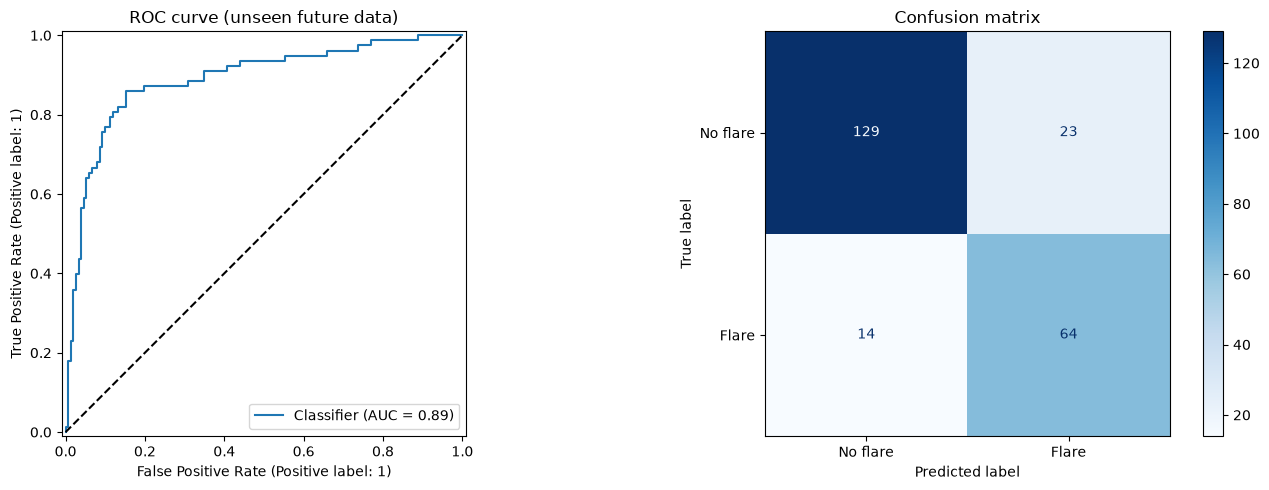


=== Top feature importances ===


,feature,importance
22,is_flare_up,0.463312
5,wind_speed,0.031049
13,pm2_5,0.030183
20,avg_hr_lag,0.027166
14,pm10,0.026742
19,total_steps_lag,0.026235
1,temperature_min,0.025716
17,sedentary_minutes_lag,0.023550
9,no,0.022494
3,pressure,0.021864


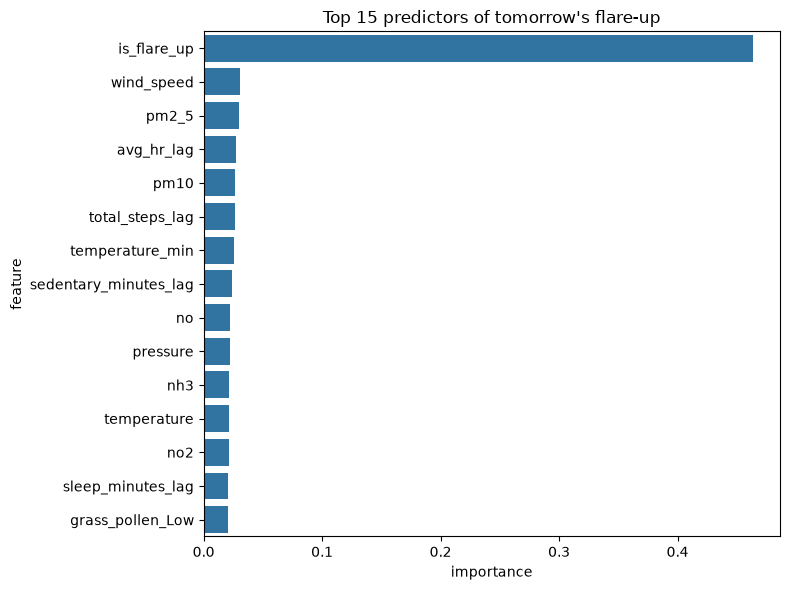


=== Train final model on all labeled rows ===
Saved model to /Users/elena0424/VS Code/ML Projects/SAIL/Mirror-Lake/asthma-app/model/artifacts/flare_classifier.joblib

=== Inference on hold-out tail ===


,user_key,date,actual,flare_probability,predicted
0,113,144,0.0,0.233359,0
1,113,145,1.0,0.375577,0
2,113,148,0.0,0.460872,0
3,113,150,0.0,0.077155,0
4,113,152,0.0,0.232375,0
5,113,153,0.0,0.172659,0
6,113,154,0.0,0.040248,0
7,113,156,0.0,0.149114,0
8,113,157,0.0,0.248152,0
9,113,158,0.0,0.140813,0


In [6]:
from sklearn.metrics import classification_report, RocCurveDisplay, ConfusionMatrixDisplay, confusion_matrix

print("=== Global chronological classifier ===")
results = evaluate_global_chronological(daily, X_cols, y_col)
print(f"Train rows: {results['train_rows']} | Hold-out rows: {results['test_rows']}")
print(f"AUC:       {results['auc']:.3f}")
print(f"Accuracy:  {results['accuracy']:.3f}")
print(f"Precision: {results['precision']:.3f}")
print(f"Recall:    {results['recall']:.3f}")
print("\nClassification report (hold-out):")
print(classification_report(results["y_test"], results["y_pred"], target_names=["No flare", "Flare"]))

print("\n=== Per-user hold-out metrics ===")
per_user_df = results["per_user_df"]
display(
    per_user_df[
        ["user_key", "n_test_rows", "n_flares", "accuracy", "precision", "recall", "auc"]
    ].sort_values("recall", ascending=False)
)
print(
    f"Mean accuracy:  {per_user_df['accuracy'].mean():.3f} | "
    f"Mean precision: {per_user_df['precision'].mean():.3f} | "
    f"Mean recall:    {per_user_df['recall'].mean():.3f}"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
RocCurveDisplay.from_predictions(results["y_test"], results["y_proba"], ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_title("ROC curve (unseen future data)")

cm = confusion_matrix(results["y_test"], results["y_pred"])
ConfusionMatrixDisplay(cm, display_labels=["No flare", "Flare"]).plot(ax=axes[1], cmap="Blues")
axes[1].set_title("Confusion matrix")
plt.tight_layout()
plt.show()

print("\n=== Top feature importances ===")
display(results["importance_df"].head(15))

fig, ax = plt.subplots(figsize=(8, 6))
top_features = results["importance_df"].head(15)
sns.barplot(data=top_features, y="feature", x="importance", ax=ax)
ax.set_title("Top 15 predictors of tomorrow's flare-up")
plt.tight_layout()
plt.show()

print("\n=== Train final model on all labeled rows ===")
final_model, train_df, feature_columns = train_final_model(daily, X_cols, y_col)
MODEL_PATH = PROJECT_ROOT / "model" / "artifacts" / "flare_classifier.joblib"
save_model(final_model, MODEL_PATH, feature_columns=feature_columns)
print(f"Saved model to {MODEL_PATH}")

print("\n=== Inference on hold-out tail ===")
_, test_df = chronological_user_split(train_df, train_fraction=0.8)
preds_df = predict_dataframe(final_model, test_df, X_cols, feature_columns, y_col=y_col)
display(preds_df[["user_key", "date", "actual", "flare_probability", "predicted"]].head(10))